Simulação Numérica das Equações de Born-Infeld


/tmp/ipykernel_41059/875411604.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return 1 + (np.sum(D**2) + np.sum(B**2))/b**2 + (np.linalg.norm(np.cross(D,B))**2)/b**4


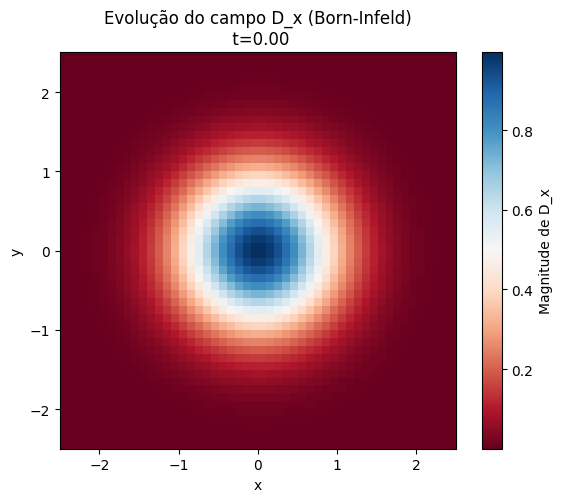

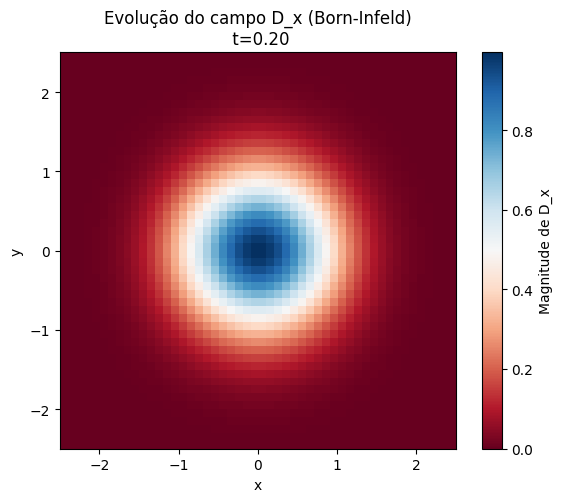

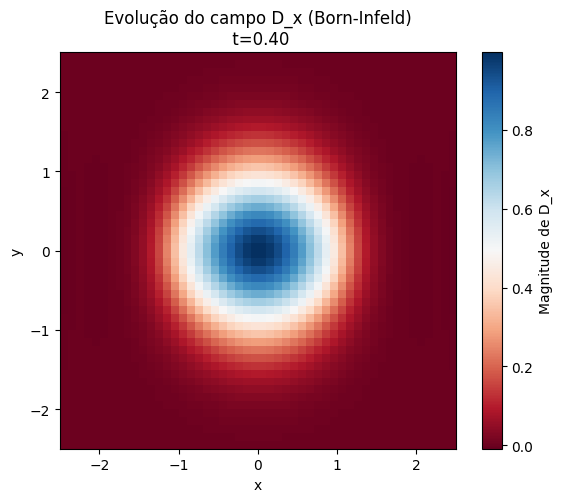

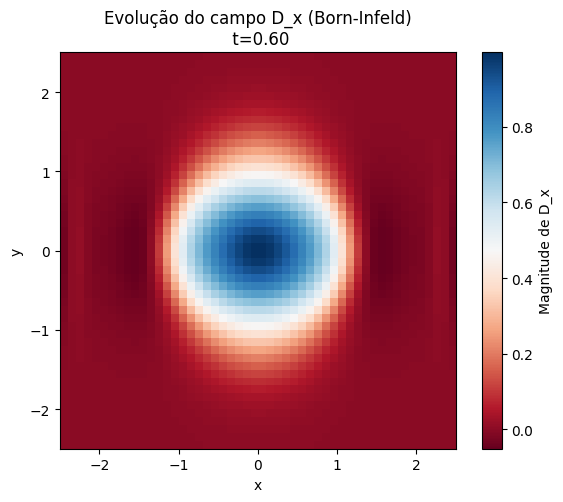

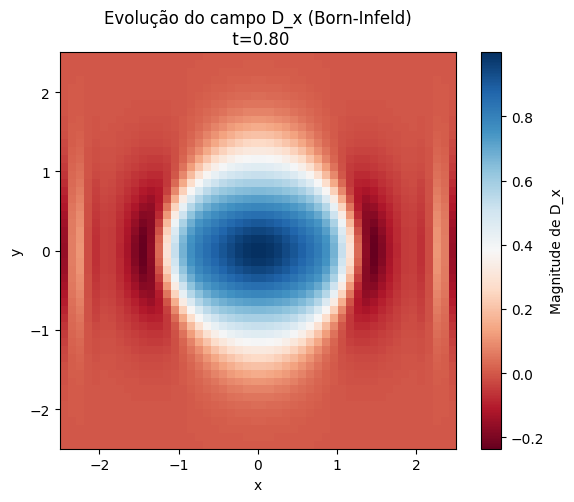

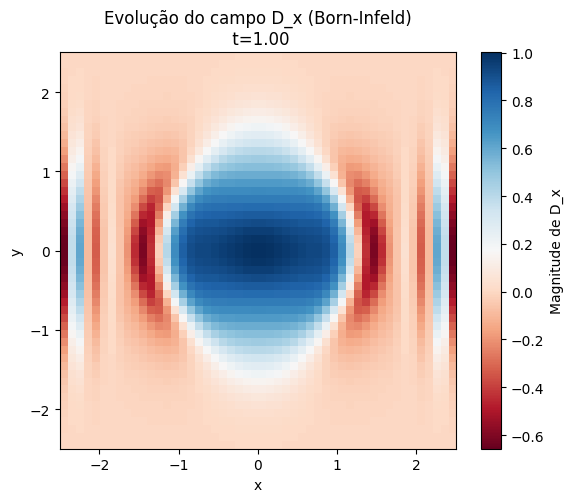

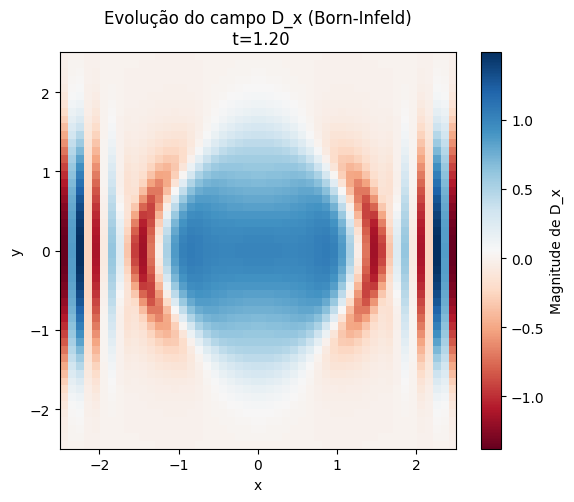

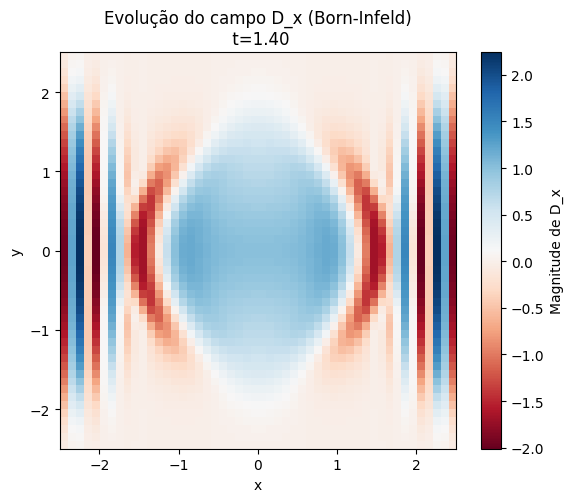

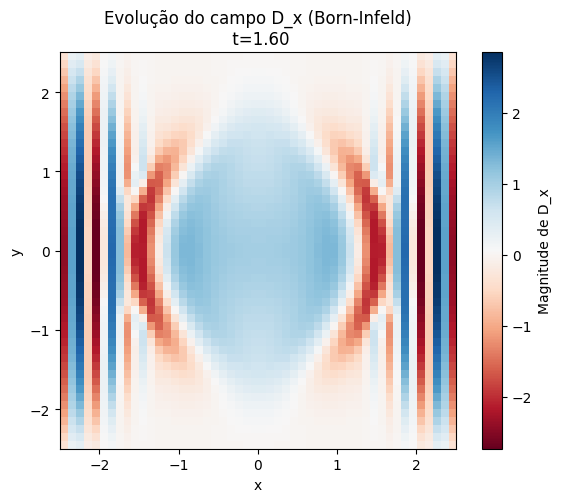

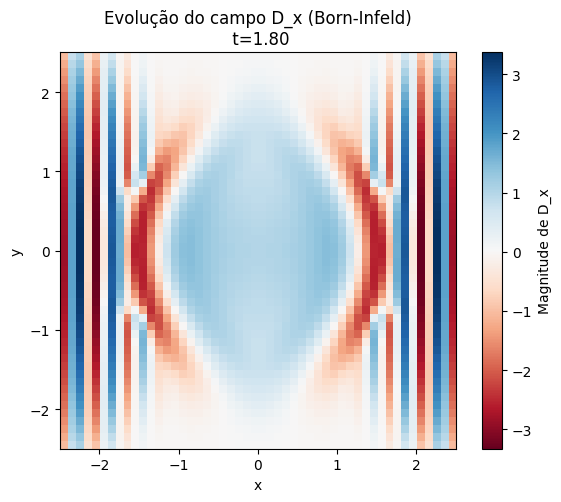

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parâmetros físicos e numéricos
# -------------------------------
b = 1.0        # parâmetro Born-Infeld
N = 1.0        # fator de normalização
nx, ny = 50, 50  # tamanho da malha espacial
dx, dy = 0.1, 0.1
dt = 0.01
steps = 200

# -------------------------------
# Funções constitutivas Born-Infeld
# -------------------------------
def R(D, B, b):
    return 1 + (np.sum(D**2) + np.sum(B**2))/b**2 + (np.linalg.norm(np.cross(D,B))**2)/b**4

def E(D, B, b):
    Rval = R(D,B,b)
    return ((b**2 + np.dot(B,B))*D - np.dot(D,B)*B)/(b**2 * Rval)

def H(D, B, b):
    Rval = R(D,B,b)
    return ((b**2 + np.dot(D,D))*B - np.dot(D,B)*D)/(b**2 * Rval)

# -------------------------------
# Operadores diferenciais (diferenças finitas)
# -------------------------------
def curl2D(Fx, Fy, dx, dy):
    """Rotacional em 2D (apenas componente z)."""
    dFy_dx = (np.roll(Fy, -1, axis=0) - np.roll(Fy, 1, axis=0))/(2*dx)
    dFx_dy = (np.roll(Fx, -1, axis=1) - np.roll(Fx, 1, axis=1))/(2*dy)
    return dFy_dx - dFx_dy

# -------------------------------
# Inicialização dos campos
# -------------------------------
D = np.zeros((nx, ny, 2))  # campo D em 2D (componentes x,y)
B = np.zeros((nx, ny, 2))  # campo B em 2D (componentes x,y)

# Condição inicial: pulso gaussiano em D_x
x = np.linspace(-nx//2, nx//2, nx)*dx
y = np.linspace(-ny//2, ny//2, ny)*dy
X, Y = np.meshgrid(x,y,indexing='ij')
D[:,:,0] = np.exp(-(X**2+Y**2))  # pulso inicial em D_x

# -------------------------------
# Evolução temporal
# -------------------------------
frames = []
for step in range(steps):
    # Calcula E e H ponto a ponto
    E_field = np.zeros_like(D)
    H_field = np.zeros_like(B)
    for i in range(nx):
        for j in range(ny):
            Dvec = D[i,j,:]
            Bvec = B[i,j,:]
            E_field[i,j,:] = E(Dvec,Bvec,b)
            H_field[i,j,:] = H(Dvec,Bvec,b)

    # Rotacionais (simplificados em 2D)
    curlH = curl2D(H_field[:,:,0], H_field[:,:,1], dx, dy)
    curlE = curl2D(E_field[:,:,0], E_field[:,:,1], dx, dy)

    # Atualização de Euler
    D[:,:,0] += dt * N * curlH
    B[:,:,0] -= dt * N * curlE

    if step % 20 == 0:
        frames.append(D[:,:,0].copy())


# -------------------------------
# Visualização: uma figura por instante
# -------------------------------
for k,frame in enumerate(frames):
    plt.figure(figsize=(6,5))
    im = plt.imshow(frame,extent=[x.min(),x.max(),y.min(),y.max()],
                    origin='lower',cmap='RdBu')
    plt.title(f"Evolução do campo D_x (Born-Infeld)\n t={k*20*dt:.2f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(im,label="Magnitude de D_x")
    plt.tight_layout()
    plt.show()
    # Se quiser salvar cada figura em arquivo:
    # plt.savefig(f"campo_Dx_t{k*20*dt:.2f}.png",dpi=300)
    plt.close()





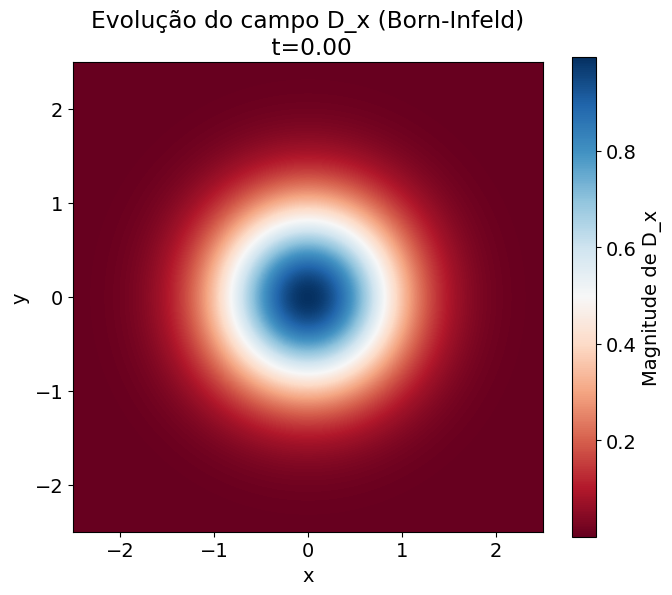

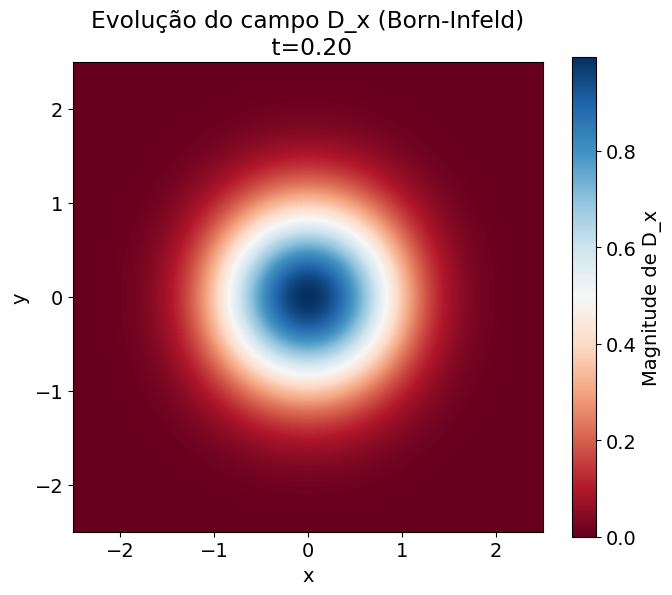

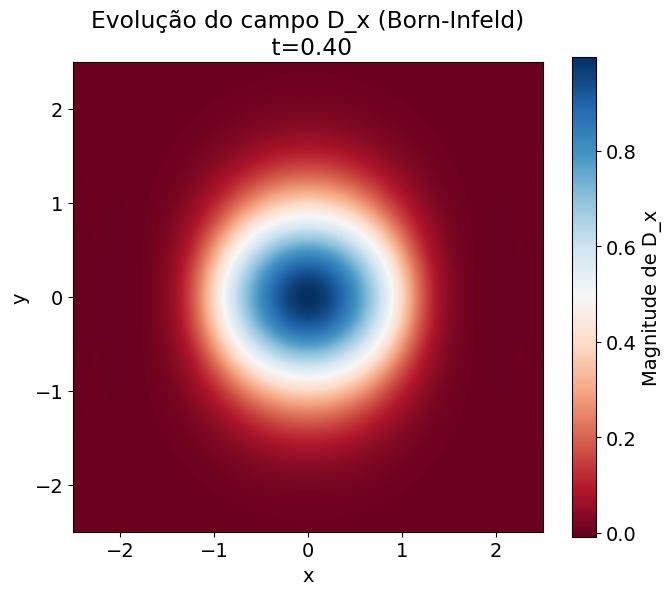

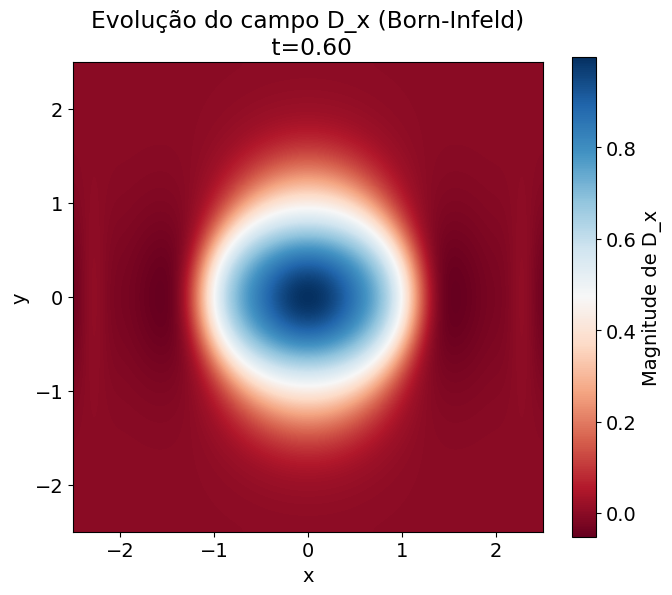

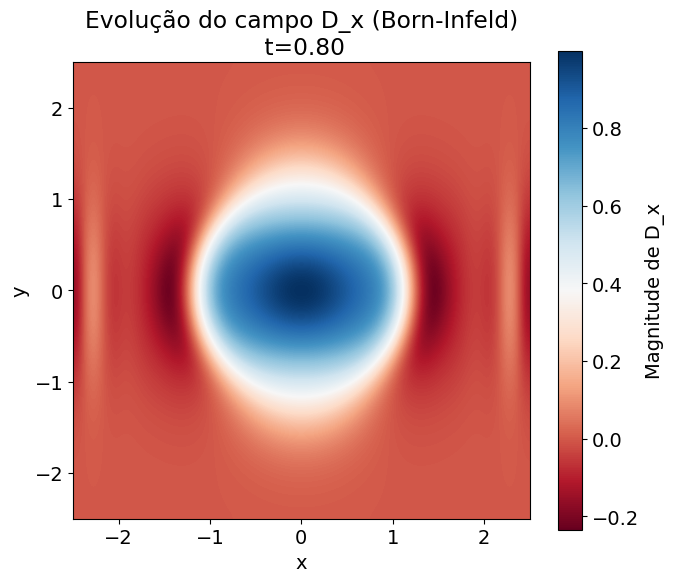

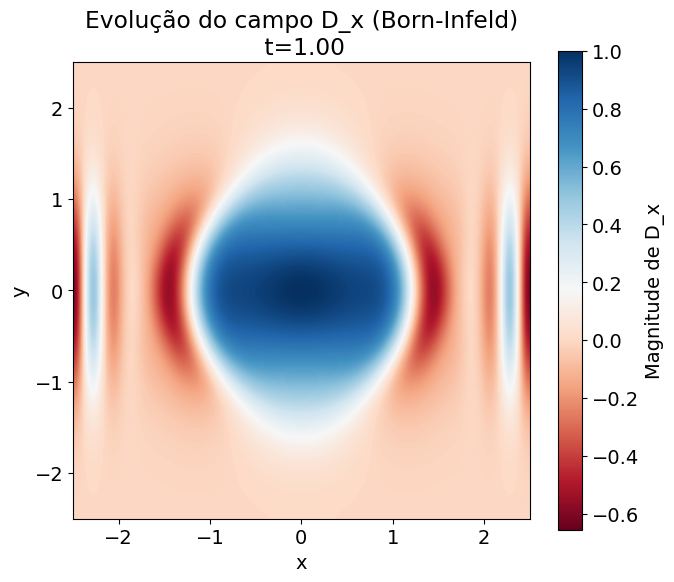

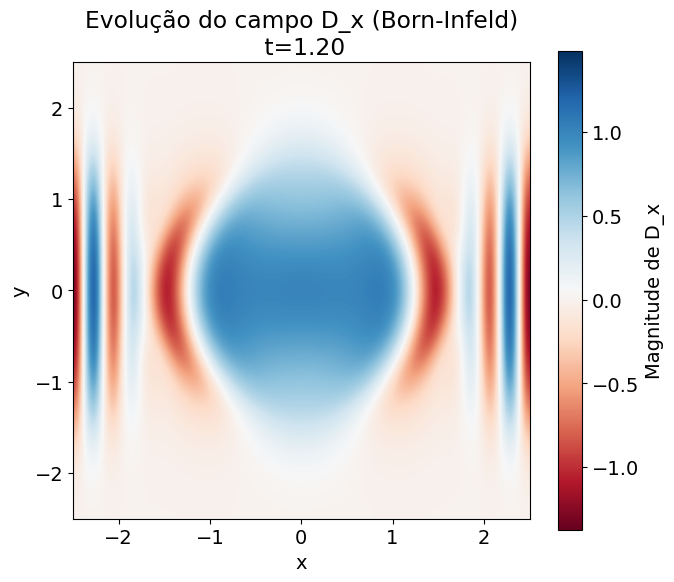

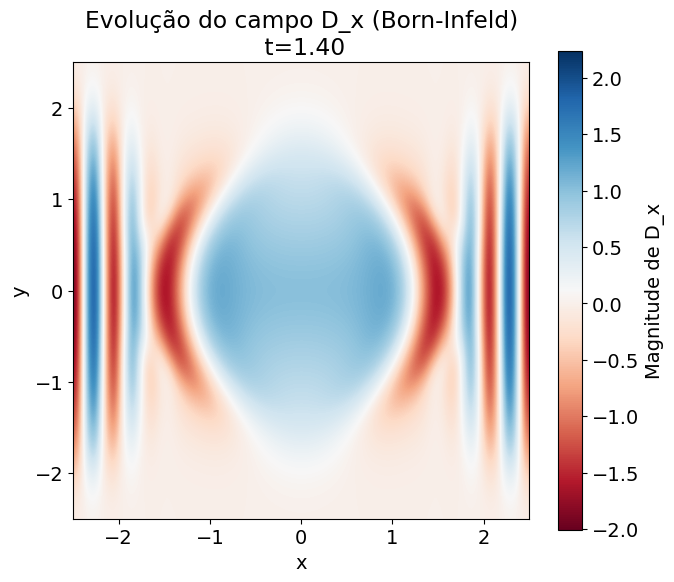

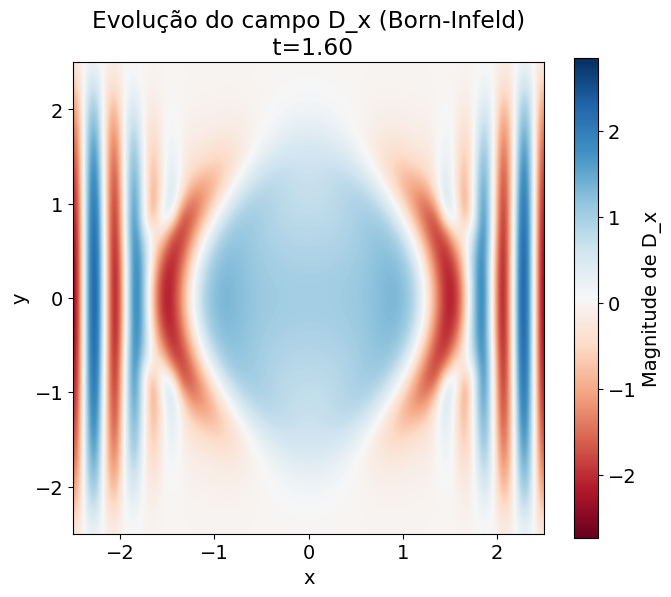

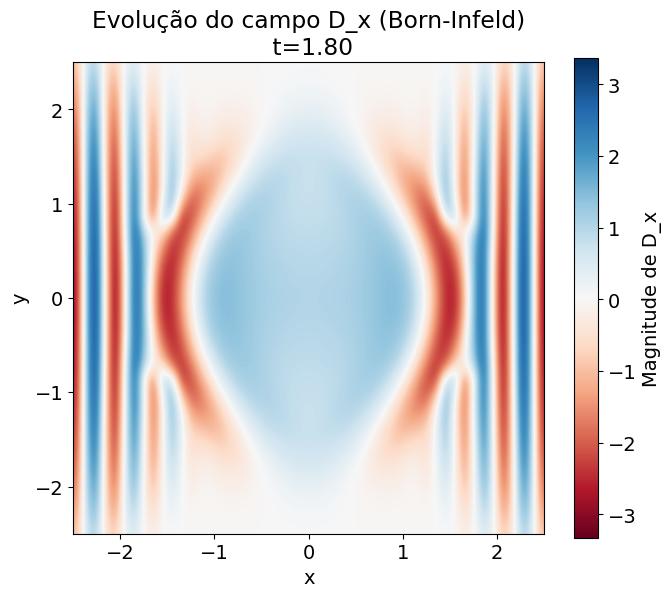

In [2]:
 #MAIS NITIDO AQUI!!!

    # -------------------------------
# Visualização: uma figura por instante (alta definição, mantendo RdBu)
# -------------------------------
plt.rcParams.update({'font.size': 14})  # fonte maior para dissertação

for k,frame in enumerate(frames):
    plt.figure(figsize=(7,6))
    im = plt.imshow(frame, extent=[x.min(),x.max(),y.min(),y.max()],
                    origin='lower', cmap='RdBu', interpolation='bicubic')
    plt.title(f"Evolução do campo D_x (Born-Infeld)\n t={k*20*dt:.2f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(im, label="Magnitude de D_x")
    plt.tight_layout()
    # Salvar em alta resolução
    plt.savefig(f"campo_Dx_t{k*20*dt:.2f}.png", dpi=300)
    plt.show()
    plt.close()





Simulação Numérica das Equações de Born-Infeld Fracionario

In [3]:
# -------------------------------
# Parâmetros físicos e numéricos
# -------------------------------
b = 1.0        # parâmetro Born-Infeld
N = 1.0        # fator de normalização
nx, ny = 50, 50  # tamanho da malha espacial
dx, dy = 0.1, 0.1
dt = 0.01
steps = 200

# -------------------------------
# Funções constitutivas Born-Infeld fracionárias
# -------------------------------




